Simulation: 100%|██████████████████████████████████████████████████████████████████| 500/500 [1:40:30<00:00, 12.06s/it]



---------------------------------------------
500 次 Simulation 的平均係數
---------------------------------------------
 Variable  OLS_beta  Ridge_beta  Lasso_beta  Attention_beta  Simulation_beta
Intercept  1.998382    1.991607    1.986037        1.989813              1.0
       X1  2.000874    1.994047    1.988430        1.992243              2.0
       X2 -1.491918   -1.486830   -1.479310       -1.485445             -1.5
       X3  0.499592    0.497927    0.487110        0.497435              0.5
       X4  0.004359    0.004407    0.003497        0.004368              0.0
       X5  3.002778    2.992469    2.990287        2.989807              3.0
       X6  0.093937    0.093580    0.085335        0.093458              0.1
       X7 -0.195195   -0.194527   -0.182943       -0.194238             -0.2
       X8  0.303689    0.302625    0.291028        0.302273              0.3
       X9 -0.397790   -0.396453   -0.385257       -0.396041             -0.4
      X10  0.503640    0.501915    0.

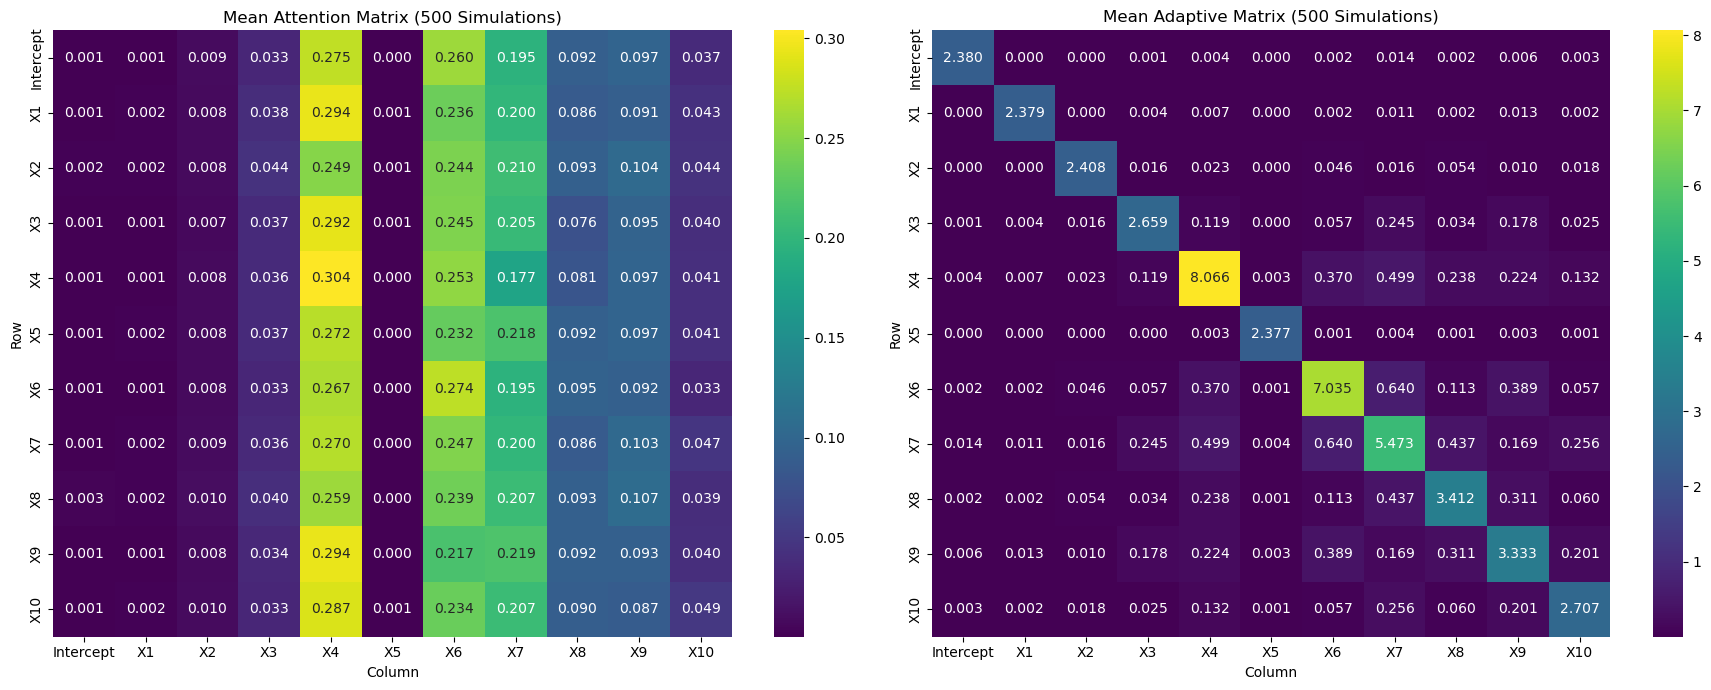

In [2]:
import numpy as np
import pandas as pd

# ==========================================
# Simulation settings
# ==========================================

n_simulations = 500

# ==========================================
# 儲存結果
# ==========================================

# 係數
beta_ols_list = []
beta_attn_list = []
beta_ridge_list = []
beta_lasso_list = []
beta_true_list = []

# 係數偏差
ols_bias_list = []
attn_bias_list = []
ridge_bias_list = []
lasso_bias_list = []

# MSE
mse_ols_list = []
mse_attn_list = []
mse_ridge_list = []
mse_lasso_list = []

# RMSE
rmse_ols_list = []
rmse_attn_list = []
rmse_ridge_list = []
rmse_lasso_list = []

# R²
ols_r2_list = []
attn_r2_list = []
ridge_r2_list = []
lasso_r2_list = []

# Attention / Adaptive matrix
attention_list = []
adaptive_list = []

# Ridge跟Lasso最好的alpha
ridge_alpha_list = []
lasso_alpha_list = []

def generate_data(seed):

    num_subjects = 1000
    num_features = 10

    rng = np.random.default_rng(seed)

    X_raw = rng.standard_normal(
        (num_subjects, num_features)
    )

    ones_column = np.ones(
        (num_subjects, 1)
    )

    X = np.concatenate(
        (ones_column, X_raw),
        axis=1
    )

    # 第一個是 intercept
    beta_true = np.array([
        1.0,   # intercept
        2.0,   # X1 effect
        -1.5,  # X2 effect
        0.5,   # X3 effect
        0.0,   # X4 no effect
        3.0,   # X5 effect
        0.1,
        -0.2,
        0.3,
        -0.4,
        0.5,
    ]).reshape(-1, 1)


    noise = rng.standard_normal(
        (num_subjects, 1)
    )

    Y = (
        X @ beta_true
        + noise
        + X[:, 2:3] * X[:, 3:4] # X2 * X3 interaction
        + X[:, 4:5] * X[:, 4:5] # X4^2 quadratic term
    )

    columns = ["Intercept"] + [f"X{i}" for i in range(1, num_features+1)]

    data = pd.DataFrame(X, columns=columns)

    data["Y"] = Y.flatten()

    return data, beta_true

from tqdm import tqdm

for sim in tqdm( range(n_simulations), desc="Simulation"):

    data_seed = sim + 1 # 可以用同一個邏輯獨立產生不同分布

    # 驗證最好的ridge_alpha

    data_for_alpha, beta_true_1 = generate_data(seed = data_seed)



    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import Ridge
    from sklearn.pipeline import Pipeline
    from sklearn.metrics import mean_squared_error


    X_alpha = data_for_alpha[
        ["Intercept"] + [f"X{i}" for i in range(1, 11)]
    ]
    Y_alpha = data_for_alpha["Y"]

    X_train_alpha = X_alpha.iloc[0:700]
    X_test_alpha = X_alpha.iloc[700:1000]

    y_train_alpha = Y_alpha.iloc[0:700]
    y_test_alpha = Y_alpha.iloc[700:1000]

    import numpy as np
    import matplotlib.pyplot as plt

    from sklearn.model_selection import KFold, cross_val_score
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import Ridge
    from sklearn.pipeline import Pipeline


    alphas = np.logspace(-4, 4, 100)

    kf = KFold(
        n_splits=10,
        shuffle=True,
        random_state=42
    )

    mse_list = []

    for alpha in alphas:

        model = Ridge(
            alpha=alpha,
            fit_intercept=False
        )

        scores = cross_val_score(
            model,
            X_train_alpha,
            y_train_alpha,
            cv=kf,
            scoring="neg_mean_squared_error"
        )

        mse = -scores.mean()

        mse_list.append(mse)

    # 找到 MSE 最小的 alpha
    best_index = np.argmin(mse_list)
    best_alpha = alphas[best_index]

    ridge_alpha_list.append(best_alpha)


    # ======================
    # 找最佳 Lasso alpha
    # ======================
    from sklearn.linear_model import Ridge, Lasso
    lasso_mse_list = []

    for alpha in alphas:

        model = Lasso(
            alpha=alpha,
            fit_intercept=False,
            max_iter=10000
        )

        scores = cross_val_score(
            model,
            X_train_alpha,
            y_train_alpha,
            cv=kf,
            scoring="neg_mean_squared_error"
        )

        mse = -scores.mean()

        lasso_mse_list.append(mse)

    best_lasso_index = np.argmin(lasso_mse_list)
    best_lasso_alpha = alphas[best_lasso_index]

    lasso_alpha_list.append(best_lasso_alpha)


    # 先讀進模擬資料

    data, beta_true = generate_data(seed = data_seed)

    cols = data.columns[:-1].to_list() 

    whole = data.copy()

    data = whole.iloc[0:700,:]

    validation = whole.iloc[700:1000,:]

    import pandas as pd
    import numpy as np

    # ### 先用傳統統計模型驗證
    X = data[cols]

    XTX = X.T @ X

    # 用套件驗證
    import statsmodels.api as sm

    X = data[cols]

    model = sm.OLS(
        data["Y"],
        X          # 不加 constant
    )

    result = model.fit()

    from sklearn.linear_model import Ridge
    from sklearn.metrics import mean_squared_error, r2_score


    # ======================
    # Split X and Y
    # ======================

    X_train = data[cols].values
    y_train = data["Y"].values

    # X_test = validation[cols].values
    # y_test = validation["Y"].values


    # ======================
    # Ridge model
    # ======================

    lam = best_alpha

    ridge = Ridge(alpha=best_alpha, fit_intercept=False)

    ridge.fit(
        X_train,
        y_train,
    )

    # ======================
    # Lasso model
    # ======================

    from sklearn.linear_model import Ridge, Lasso
    lasso = Lasso(
        alpha=best_lasso_alpha,
        fit_intercept=False,
        max_iter=10000
    )

    lasso.fit(
        X_train,
        y_train,
    )

    import torch

    X = torch.tensor(
        data[cols].values,
        dtype=torch.float32
    )

    y = torch.tensor(
        data["Y"].values,
        dtype=torch.float32
    )

    N = X.shape[0]
    P = X.shape[1]

    import torch.nn as nn

    y = y.reshape(-1, 1)

    X_Y_train = X

    X_Y_features = X_Y_train.t()

    d_k = 49

    # d_k = 32**2
    W_Q = nn.Linear(
        X_Y_features.shape[1],
        d_k,
        bias=False
    )

    W_K = nn.Linear(
        X_Y_features.shape[1],
        d_k,
        bias=False
    )

    optimizer = torch.optim.Adam(

        list(W_Q.parameters()) +
        list(W_K.parameters()), 
        
        lr=0.001

    )

    import numpy as np
    import torch.nn.functional as F


    # Deep GLM 
    p = X.shape[1]

    I = torch.eye(
        p,
        dtype=X.dtype,
        device=X.device
    )

    loss_history = []

    initial_attn = None

    epochs = 1000

    for epoch in range(epochs):

        Q = W_Q(X_Y_features)
        
        K = W_K(X_Y_features)

        scores = torch.matmul(
            Q,
            K.transpose(-2,-1)
        ) 

        # scores = scores / np.sqrt(dk)

        attention_matrix = F.softmax(
            scores / (d_k ** 0.5), 
            dim=-1
        )

        # 只看X之間
        A = attention_matrix

        # # 矩陣乘上Y的變異數
        # var_y = torch.var(y)

        # A_var_y = A * var_y


        # beta

        beta = torch.linalg.solve(X.T @ X + 3 * (I + A.T@A),X.T @ y) # torch.linalg.solve(X.T @ X + I + A.T@A/torch.trace(A),X.T @ y)
        
        y_hat = X @ beta

        loss = F.mse_loss(
            y_hat,
            y
        )


        if epoch == 0:
            initial_attn = attention_matrix.detach().clone()


        loss_history.append(
            loss.item()
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    # =====================
    # 訓練完成後重新 forward
    # 取得最後 attention
    # =====================

    with torch.no_grad():

        Q = W_Q(X_Y_features)
        
        K = W_K(X_Y_features)

        scores = torch.matmul(
            Q,
            K.transpose(-2,-1)
        ) 

        # scores = scores / np.sqrt(dk)

        attention_matrix = F.softmax(
            scores / (d_k ** 0.5), 
            dim=-1
        )

        # 只看X之間
        A = attention_matrix

        final_attn = A.clone()

        # # 矩陣乘上Y的變異數
        # var_y = torch.var(y)

        # # A_var_y = A * var_y


        # beta

        beta1 = torch.linalg.solve(X.T @ X + 3 * (I + A.T@A),X.T @ y) # torch.linalg.solve(X.T @ X + I + A.T@A/torch.trace(A),X.T @ y)

        # adaptive

        adaptive = lam * (I + A.T@A)


    attn_matrix = final_attn.detach().flatten()

    ### 做驗證

    beta_ols = result.params.values
    beta_attn = beta1.detach().numpy()
    beta_attn = beta_attn.flatten()
    beta_ridge = ridge.coef_
    beta_lasso = lasso.coef_

    X_val = validation[cols].values
    y_val = validation["Y"].values

    y_pred_ols = X_val @ beta_ols

    y_pred_attn = X_val @ beta_attn

    y_pred_ridge = X_val @ beta_ridge

    y_pred_lasso = X_val @ beta_lasso

    from sklearn.metrics import mean_squared_error

    mse_ols = mean_squared_error(
        y_val,
        y_pred_ols
    )

    mse_attn = mean_squared_error(
        y_val,
        y_pred_attn
    )

    mse_ridge = mean_squared_error(
        y_val,
        y_pred_ridge
    )

    mse_lasso = mean_squared_error(
        y_val,
        y_pred_lasso
    )

    rmse_ols = np.sqrt(mse_ols)
    rmse_attn = np.sqrt(mse_attn)
    rmse_ridge = np.sqrt(mse_ridge)
    rmse_lasso = np.sqrt(mse_lasso)

    from sklearn.metrics import r2_score

    ols_r2 = r2_score(y_val, y_pred_ols)
    attn_r2 = r2_score(y_val, y_pred_attn)
    ridge_r2 = r2_score(y_val, y_pred_ridge)
    lasso_r2 = r2_score(y_val, y_pred_lasso)

    # 模擬資料生成時的實際係數
    beta_true = beta_true.flatten()

    ols_bias = abs(beta_ols - beta_true)
    attn_bias = abs(beta_attn - beta_true)
    ridge_bias = abs(beta_ridge - beta_true)
    lasso_bias = abs(beta_lasso - beta_true)

    Adaptive = adaptive.detach().numpy()

    Attention = final_attn.detach().numpy()

    # ======================================
    # 把這一次結果存進 list
    # ======================================

    # coefficients

    beta_ols_list.append(
        beta_ols
    )

    beta_attn_list.append(
        beta_attn
    )

    beta_ridge_list.append(
        beta_ridge
    )

    beta_lasso_list.append(
        beta_lasso
    )

    beta_true_list.append(
        beta_true
    )

    # bias

    ols_bias_list.append(
        ols_bias
    )

    attn_bias_list.append(
        attn_bias
    )

    ridge_bias_list.append(
        ridge_bias
    )

    lasso_bias_list.append(
        lasso_bias
    )

    # MSE

    mse_ols_list.append(mse_ols)
    mse_attn_list.append(mse_attn)
    mse_ridge_list.append(mse_ridge)
    mse_lasso_list.append(mse_lasso)


    # RMSE

    rmse_ols_list.append(rmse_ols)
    rmse_attn_list.append(rmse_attn)
    rmse_ridge_list.append(rmse_ridge)
    rmse_lasso_list.append(rmse_lasso)


    # R²

    ols_r2_list.append(ols_r2)
    attn_r2_list.append(attn_r2)
    ridge_r2_list.append(ridge_r2)
    lasso_r2_list.append(lasso_r2)

    # Matrix

    attention_list.append(
        Attention
    )

    adaptive_list.append(
        Adaptive
    )

beta_ols_mean = np.mean(
    beta_ols_list,
    axis=0
)

beta_attn_mean = np.mean(
    beta_attn_list,
    axis=0
)

beta_ridge_mean = np.mean(
    beta_ridge_list,
    axis=0
)

beta_lasso_mean = np.mean(
    beta_lasso_list,
    axis=0
)

beta_true_mean = np.mean(
    beta_true_list,
    axis=0
)

ols_bias_mean = np.mean(
    ols_bias_list,
    axis=0
)

attn_bias_mean = np.mean(
    attn_bias_list,
    axis=0
)

ridge_bias_mean = np.mean(
    ridge_bias_list,
    axis=0
)

lasso_bias_mean = np.mean(
    lasso_bias_list,
    axis=0
)

mse_ols_mean = np.mean(mse_ols_list)
mse_attn_mean = np.mean(mse_attn_list)
mse_ridge_mean = np.mean(mse_ridge_list)
mse_lasso_mean = np.mean(mse_lasso_list)

rmse_ols_mean = np.mean(rmse_ols_list)
rmse_attn_mean = np.mean(rmse_attn_list)
rmse_ridge_mean = np.mean(rmse_ridge_list)
rmse_lasso_mean = np.mean(rmse_lasso_list)

ols_r2_mean = np.mean(ols_r2_list)
attn_r2_mean = np.mean(attn_r2_list)
ridge_r2_mean = np.mean(ridge_r2_list)
lasso_r2_mean = np.mean(lasso_r2_list)

beta_mean_table = pd.DataFrame({
    "Variable": cols,
    "OLS_beta": beta_ols_mean,
    "Ridge_beta": beta_ridge_mean,
    "Lasso_beta": beta_lasso_mean,
    "Attention_beta": beta_attn_mean,
    "Simulation_beta": beta_true_mean
})

print("\n---------------------------------------------")
print(f"{n_simulations} 次 Simulation 的平均係數")
print("---------------------------------------------")
print(
    beta_mean_table.round(6)
    .to_string(index=False)
)

print("")
print(
    f"OLS平均係數偏差: "
    f"{ols_bias_mean.sum():.6f}"
)

print(
    f"Ridge平均係數偏差: "
    f"{ridge_bias_mean.sum():.6f}"
)

print(
    f"Lasso平均係數偏差: "
    f"{lasso_bias_mean.sum():.6f}"
)

print(
    f"DeepGLM平均係數偏差: "
    f"{attn_bias_mean.sum():.6f}"
)
print("-"*52)

print("\n----------------------------------------------------")
print(f"{n_simulations} 次 Simulation 平均表現")
print("----------------------------------------------------")

print(
    f"{'Model':<12}"
    f"{'MSE':>12}"
    f"{'RMSE':>12}"
    f"{'R²':>12}"
)

print("-"*52)

print(
    f"{'OLS':<12}"
    f"{mse_ols_mean:>12.6f}"
    f"{rmse_ols_mean:>12.6f}"
    f"{ols_r2_mean:>12.6f}"
)

print(
    f"{'Ridge':<12}"
    f"{mse_ridge_mean:>12.6f}"
    f"{rmse_ridge_mean:>12.6f}"
    f"{ridge_r2_mean:>12.6f}"
)

print(
    f"{'Lasso':<12}"
    f"{mse_lasso_mean:>12.6f}"
    f"{rmse_lasso_mean:>12.6f}"
    f"{lasso_r2_mean:>12.6f}"
)

print(
    f"{'Attention':<12}"
    f"{mse_attn_mean:>12.6f}"
    f"{rmse_attn_mean:>12.6f}"
    f"{attn_r2_mean:>12.6f}"
)

print("-"*52)
print("")

## alpha selection
print("Ridge CV 選出的平均 alpha")
print(np.mean(ridge_alpha_list))
print("")

print("DeepGLM 使用的平均 lambda")
print(np.mean(ridge_alpha_list))
print("")

print("Lasso CV 選出的平均 alpha")
print(np.mean(lasso_alpha_list))
print("")

attention_array = np.array(
    attention_list
)

adaptive_array = np.array(
    adaptive_list
)

attention_mean = np.mean(
    attention_array,
    axis=0
)

adaptive_mean = np.mean(
    adaptive_array,
    axis=0
)

Attention_mean = pd.DataFrame(
    attention_mean,
    index=cols,
    columns=cols
)

Adaptive_mean = pd.DataFrame(
    adaptive_mean,
    index=cols,
    columns=cols
)

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 7)
)

# ==========================================
# Average Attention
# ==========================================

sns.heatmap(
    Attention_mean,
    ax=axes[0],
    xticklabels=cols,
    yticklabels=cols,
    annot=True,
    fmt=".3f",
    cmap="viridis"
)

axes[0].set_title(
    f"Mean Attention Matrix ({n_simulations} Simulations)"
)

axes[0].set_xlabel("Column")
axes[0].set_ylabel("Row")


# ==========================================
# Average Adaptive
# ==========================================

sns.heatmap(
    Adaptive_mean,
    ax=axes[1],
    xticklabels=cols,
    yticklabels=cols,
    annot=True,
    fmt=".3f",
    cmap="viridis"
)

axes[1].set_title(
    f"Mean Adaptive Matrix ({n_simulations} Simulations)"
)

axes[1].set_xlabel("Column")
axes[1].set_ylabel("Row")

plt.tight_layout()
plt.show()